<a href="https://colab.research.google.com/github/Rukaya-lab/Engineering-ML-Features-for-MOF-CO2-Adsorption/blob/main/Full_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Import Libraries

In [ ]:
import pandas as pd

In [ ]:
!pip install 'numpy == 1.23.0'

In [ ]:
!pip install 'ase == 3.19.1'

In [ ]:
!pip install pandas

In [ ]:
import ase
import json
import numpy as np

import matplotlib.pyplot as plt


from ase.io import read
from ase import build

from scipy import special
from scipy.spatial import distance

### Generate Rotations

In [ ]:
'''
#to generate random rotations about a grid point
#this should be an once and then translated for each grid points
def generate_random_orientations(n_orientations, grid_point, grid_radius):
    orientations = {}
    #for grid_point in grid_points:
        # Generate  random orientations for CO2[O1] and CO2[O2]
    co2_o1 = []
    co2_o2 = []
    co2_c =[]

    for _ in range(n_orientations):
        # Generate random orientations for CO2[O1] and CO2[O2] relative to CO2[C]
        # Random values within the circumference of the grid
        phi = np.random.uniform(0, 2*np.pi)
        theta = np.random.uniform(0, np.pi)
        r = grid_radius

        x_o1 = grid_point[0] + ( r * np.sin(phi) * np.cos(theta))
        x_o2 = grid_point[0] - ( r * np.sin(phi) * np.cos(theta))

        #theta = np.arccos(np.random.uniform(-1, 1))  # #add cos theta from -1 to 1 for uniformity
        y_o1 = grid_point[1] + ( r * np.sin(phi) * np.sin(theta))
        y_o2 = grid_point[1] - ( r * np.sin(phi) * np.sin(theta))

        # Random values for  z-coordinates
        z_o1 = grid_point[2] + ( r * np.cos(phi))
        z_o2 = grid_point[2] + ( r * np.cos(phi))

        # Store orientations in the dictionary
        co2_o1.append({'X': x_o1, 'Y': y_o1, 'Z': z_o1})
        co2_o2.append({'X': x_o2, 'Y': y_o2, 'Z': z_o2})

    co2_c.append({'X': grid_point[0], 'Y': grid_point[1], 'Z': grid_point[2]})

    orientations = {'CO2[C]': co2_c, 'CO2[O1]': co2_o1, 'CO2[O2]': co2_o2}

    return orientations
'''

"\n#to generate random rotations about a grid point\n#this should be an once and then translated for each grid points\ndef generate_random_orientations(n_orientations, grid_point, grid_radius):\n    orientations = {}\n    #for grid_point in grid_points:\n        # Generate  random orientations for CO2[O1] and CO2[O2]\n    co2_o1 = []\n    co2_o2 = []\n    co2_c =[]\n\n    for _ in range(n_orientations):\n        # Generate random orientations for CO2[O1] and CO2[O2] relative to CO2[C]\n        # Random values within the circumference of the grid\n        phi = np.random.uniform(0, 2*np.pi)\n        theta = np.random.uniform(0, np.pi)\n        r = grid_radius\n\n        x_o1 = grid_point[0] + ( r * np.sin(phi) * np.cos(theta))\n        x_o2 = grid_point[0] - ( r * np.sin(phi) * np.cos(theta))\n\n        #theta = np.arccos(np.random.uniform(-1, 1))  # #add cos theta from -1 to 1 for uniformity\n        y_o1 = grid_point[1] + ( r * np.sin(phi) * np.sin(theta))\n        y_o2 = grid_point[1

In [ ]:
'''
grid_point = (0,0,0)
n_orientations = 50
grid_radius = 1.16
orientations = generate_random_orientations(n_orientations, grid_point, grid_radius)


# Save orientations to a JSON file
with open('/content/drive/MyDrive/UoM Dissertation/rotations_around_grid.json', 'w') as f:
    json.dump(orientations, f)
'''

"\ngrid_point = (0,0,0)\nn_orientations = 50\ngrid_radius = 1.16\norientations = generate_random_orientations(n_orientations, grid_point, grid_radius)\n\n\n# Save orientations to a JSON file\nwith open('/content/drive/MyDrive/UoM Dissertation/rotations_around_grid.json', 'w') as f:\n    json.dump(orientations, f)\n"

In [ ]:
!pip install --upgrade numpy

In [ ]:
import numpy

##Load the CIF atom file

In [ ]:
#list of effective neighbor atoms based on the wall atom
input_addr ="/content/1.cif"
####generate supercell####
# Read in the CIF file
print("reading "+input_addr)
atoms = read(input_addr)

reading /content/1.cif


### Accessing

In [ ]:
cif=np.loadtxt(input_addr, delimiter='|',dtype=str)
contains_ab = np.vectorize(lambda x: '_atom_site_charge' in x)
#fetch the valid atoms descriptors and values
valid_content = cif[np.where(contains_ab(cif))[0][0]+1:]
split_array=np.char.split(valid_content)
#the last line in the cif file containing the charges per atoms
charges_origin=np.array([list(item) for item in split_array])[:,-1].astype(float).tolist()
#set the charges as the atoms charges
atoms.set_initial_charges(charges=charges_origin)
#print(len(atoms.get_initial_charges()))
cutoff=12

In [ ]:
#make supercell to meet LJ cut-off requirement
xlength=np.linalg.norm(atoms.get_cell()[0])
ylength=np.linalg.norm(atoms.get_cell()[1])
zlength=np.linalg.norm(atoms.get_cell()[2])

#how many times to repeat the unit cell in each direction
#doubling the cut off to ensure the supercell is large enough to accomodate interactions with cut off
if cutoff*2%xlength==0: mul_x=int(cutoff*2/xlength)
else: mul_x=int(cutoff*2/xlength)+1
if cutoff*2 % ylength==0: mul_y=int(cutoff*2/ylength)
else: mul_y=int(cutoff*2/ylength)+1
if cutoff*2%zlength==0: mul_z=int(cutoff*2/zlength)
else: mul_z=int(cutoff*2/zlength)+1

In [ ]:
#Get Cell characteristics
supercell = ase.build.make_supercell(atoms, [[mul_x, 0.0, 0.0], [0.0, mul_y, 0.0], [0.0, 0.0, mul_z]])
print(supercell)
#supercell.positions
#store symbols
symbols=supercell.get_chemical_symbols()
positions=supercell.get_positions() #works as an np.dot(scaled (atoms), cell)
#scale the positions to unit cell, originally stored in the cif file
scaled_positions=supercell.get_scaled_positions()
#get the cell
unitcell= supercell.get_cell() #why is it not diagonal matrix, where did the extra values come from
print(unitcell)
#inverse of unit cell, such that multiplication with unitcell result in identity matrix
inv_unitcell=np.linalg.inv(unitcell)

range_supercell=range(len(supercell))
#all_distances=supercell.get_all_distances(mic=True)
charges=supercell.get_initial_charges()

Atoms(symbols='C768H448O448Zn128', pbc=True, cell=[28.9976, 34.3318, 36.3072], initial_charges=...)
Cell([28.9976, 34.3318, 36.3072])


## Load LJ Parameters for Atoms

In [ ]:
#load file contaiong epsilon and sigma of atoms
df = pd.read_csv("/content/LJ.csv")
df.head()

,Name,epsilon/K,sigma/A
0,Ac,16.60,3.10
1,Ag,18.11,2.80
2,Al,254.09,4.01
3,Am,7.04,3.01
4,Ar,93.08,3.45


In [ ]:

arr= df.to_numpy()
#slice to get epsilon and sigma values
epsilon_dict = dict(zip(arr[:,0], arr[:,1]))
sigma_dict = dict(zip(arr[:,0], arr[:,2]))
#specific epsilon and sigma values of atoms
epsilon_arr=np.array([epsilon_dict[element] for element in symbols])
sigma_arr=np.array([sigma_dict[element] for element in symbols])

diameter_dict=dict(zip(arr[:,0], arr[:,2]))
diameter_dict['H'] = 1.0 #Hydrogen diameter correction
diameter_arr=np.array([diameter_dict[element] for element in symbols])
#supercell.write('mystructure_supercell.cif')

### Read force fields paramaters for CO2

In [ ]:
#read force field for atoms in CO2

epsilon_gas_C,sigma_gas_C=27.000000,2.800000 #K, Ang
epsilon_gas_O,sigma_gas_O=79.000000,3.050000
r_gas = 1.65 #kinectic diameter of CO2 is 3.3 angstrom, r_gas now is 1.65
#r_gas<C> = sigma_gas<C>/2
r_max = 4.2/2  #what is 4.2
q_gas_O=-0.350
q_gas_C=0.700
#q_gas=0

## Generate points on the Surface of atoms

In [ ]:
#a function to generate random points on the nearby surface of an atom
import random
import math
import numpy as np

def set_probe(r_gas,r_wall,n):
    # Generate random spherical coordinates
    theta = np.random.uniform(0, 2*math.pi,n)
    phi = np.random.uniform(0, math.pi,n)

    # Convert spherical coordinates to Cartesian coordinates
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)

    r=r_gas+r_wall

    x=x*r
    y=y*r
    z=z*r

    return np.array([x,y,z]).T

In [ ]:
#generate surface for each atom
surface_list=[]

probe_point_paramater=100  ##as hyperparameter, reduce how many points to probe on the sphere

weighted_surface= 4*np.pi*(r_gas+1.5)*(r_gas+1.5) #used for unifying surface density
for i in range_supercell:
    atom = supercell[i]
    r_wall = diameter_dict[atom.symbol]/2

    n_point = int(probe_point_paramater/weighted_surface*(4*np.pi*(r_gas+r_wall)*(r_gas+r_wall)))


    #generate sphere for each atom
    sphere=atom.position + set_probe(r_gas, r_wall, n=n_point)
    r_sphere = r_gas + r_wall
    #area per point
    area_point=4*np.pi*r_sphere*r_sphere/n_point

    #transforms the generated spheres to scaled cordinates
    sphere_scaled_positions=np.dot(sphere, inv_unitcell)
    #first set a neighbor list based on the wall atom, which is used for identifing surface
    #all_distances_i=all_distances[i]
    #get distance of atom i with other atoms
    #minimum image convention
    all_distances_i= supercell.get_distances(i,range_supercell,mic=True)
    r_neighbor=r_wall+r_gas*2+r_max
    #filter through by distances
    sort_neighbor=np.logical_and(all_distances_i>0.0,all_distances_i<r_neighbor)
    neighbor_wallatoms=supercell[sort_neighbor]
    neighbor_diameter=diameter_arr[sort_neighbor]
    neighbor_scaled_positions=neighbor_wallatoms.get_scaled_positions()
    neighbor_symbols=neighbor_wallatoms.get_chemical_symbols()

    #identify the points on the sphere belonging to the surface, and gather surfaces together
    for j in range(sphere.shape[0]):
        #make sphere point at the center of the box to reduce distance calculation cost due to periodic boundary condition
        neighbor_scaled_positions_opt= neighbor_scaled_positions + np.round(sphere_scaled_positions[j] - neighbor_scaled_positions) #???ask for explanation here
        neighbor_positions_opt=np.dot(neighbor_scaled_positions_opt,unitcell)
        neighbor_distances= np.linalg.norm(sphere[j]-neighbor_positions_opt,axis=1)
        #surface points should be away enough from the neighbor wall atoms(> r_gas+r_wall)
        neighbor_min_dist = neighbor_diameter/2+r_gas
        #if not overlapping, then append those surfaces for enrgy calculation
        if np.all(neighbor_distances-neighbor_min_dist>0):
            surfacepoint=sphere[j].tolist()
            #add the area of each surface point to the list
            surfacepoint.append(area_point)
            surface_list.append(surfacepoint)

In [ ]:
volume = supercell.get_volume() #Angstrom^2/u.c.
print(volume)
mass = np.sum(supercell.get_masses())/(6.02214076e23) #g/u.c. #using avogadro's constant to convert to grams
print(mass)
density=mass/volume*1e24 #g/cm^3
print(density)
np.savetxt('density.txt', [density])

#if no surfaces found
if surface_list==[]:
    np.savetxt('surface_features.txt', [0.0]*801)


36145.26276017046
4.1865882922338075e-20
1.1582674941423123


## Compute Energy

In [ ]:
def calculate_energy(surface_positions, surface_scaled_positions, scaled_positions, unitcell, epsilon_arr, sigma_arr, charges, epsilon_gas, sigma_gas, q_gas):

    '''
    surface positions: are the individual points of probe, surface scaled positions are the scaled version, scaled positions are scaled frame work atoms,

    '''
   #individual positions
    point_position=surface_positions
    #the scaled version
    point_scaled_position=surface_scaled_positions
    #make sphere point at the center of the box to reduce distance calculation cost due to periodic boundary condition
    scaled_positions_opt = scaled_positions + np.round(point_scaled_position-scaled_positions) #???
    #rescale to box size
    positions_opt=np.dot(scaled_positions_opt,unitcell)
    #difference of surface positions and framework positions
    point_distances=np.linalg.norm(point_position-positions_opt,axis=1)


  #LJ potential calculation
    lj_arr=np.vstack((point_distances,epsilon_arr,sigma_arr,charges)).T
    #filter out those with distances greater than cutoff
    lj_arr=lj_arr[lj_arr[:,0]<cutoff]

    #framework and gas LJ parameters mixing rule
    epsilon_mixingrule = np.sqrt(lj_arr[:,1]*epsilon_gas)
    sigma_mixingrule = (lj_arr[:,2]+sigma_gas)/2

    #define LJ and coulumbic variables
    distance=lj_arr[:,0]
    epsilon=epsilon_mixingrule
    sigma=sigma_mixingrule
    q_atom=lj_arr[:,3]
    #lennard jones energy calculation
    U_lj=np.sum(4*epsilon*(np.power(sigma/distance,12)-np.power(sigma/distance,6)))*0.0083115 #0.0083115Kelvin to kJ/mol
    #coulombic interaction calculation
    qq=q_gas*q_atom
    #Wolf's method of calculation
    U_q=np.sum(1e-3*6.022e23*9e19*1.602176634e-19*1.602176634e-19*(qq/distance*(1-special.erf(0.15*distance))-qq/cutoff*(1-special.erf(0.15*cutoff))))
    #U_list.append(U_lj+U_q)
    #Ulj_list.append(U_lj)
    #Uq_list.append(U_q)
    lj_E = U_lj
    q_E = U_q
    total_E = lj_E + q_E
    return lj_E,q_E, total_E


In [ ]:

surface_arr=np.array(surface_list)
surface_positions=surface_arr[:,0:3] #extract just the coordinates and not the area
#scale the surface positions to unit cell
surface_scaled_positions=np.dot(surface_positions,inv_unitcell)


In [ ]:
#compute energy on surface based on surface list, taking probe as C
U_list=[] # total energy as a sum of LJ and coulumbic interaction
Ulj_list=[]
Uq_list=[]

for k in range(len(surface_list)):
    surface = surface_positions[k]

    surface_scaled= surface_scaled_positions[k]
    energies = calculate_energy(surface_positions=surface, surface_scaled_positions=surface_scaled, scaled_positions=scaled_positions,
                    unitcell=unitcell, epsilon_arr=epsilon_arr, sigma_arr=sigma_arr, charges=charges, epsilon_gas=epsilon_gas_C, sigma_gas=sigma_gas_C, q_gas=q_gas_C)
    U_list.append(energies[2])
    Ulj_list.append(energies[0])
    Uq_list.append(energies[1])


### Add orientations of O

In [ ]:
#load saved orientations
with open('/content/drive/MyDrive/UoM Dissertation/rotations_around_grid.json', 'r') as f:
   orientations = json.load(f)

In [ ]:
def convert_to_array(rotation_list):
    return np.array([[point['X'], point['Y'], point['Z']] for point in rotation_list])

In [ ]:
O1_rotations = convert_to_array(np.array(orientations['CO2[O1]']))
O2_rotations = convert_to_array(np.array(orientations['CO2[O2]']))

In [ ]:
print(len(U_list))

11995


In [ ]:
print(len(surface_positions))

11995


In [ ]:
'''
total_LJ_list = []
total_q_list = []
total_E_list = []

for p in range(len(surface_positions)):
    # Translate points
    translated_o1 = surface_positions[p] + O1_rotations
    translated_o2 = surface_positions[p] - O1_rotations

    # Scale the positions to unit cell
    scaled_o1 = np.dot(translated_o1, inv_unitcell)
    scaled_o2 = np.dot(translated_o2, inv_unitcell)

    # Lists to hold energies for the current surface position point
    current_LJ = []
    current_q = []
    current_E = []

    for k in range(len(scaled_o1)):
        surface_O1 = translated_o1[k]
        surface_O2 = translated_o2[k]

        surface_scaled_O1 = scaled_o1[k]
        surface_scaled_O2 = scaled_o2[k]

        # Interpolate energies for translated points
        energies_o1 = calculate_energy(
            surface_O1, surface_scaled_O1, scaled_positions, unitcell, epsilon_arr, sigma_arr, charges,
            epsilon_gas=epsilon_gas_O, sigma_gas=sigma_gas_O, q_gas=q_gas_O
        )
        energies_o2 = calculate_energy(
            surface_O2, surface_scaled_O2, scaled_positions, unitcell, epsilon_arr, sigma_arr, charges,
            epsilon_gas=epsilon_gas_O, sigma_gas=sigma_gas_O, q_gas=q_gas_O
        )

        # Append energies to the current lists
        current_LJ.append(energies_o1[0] + energies_o2[0])
        current_q.append(energies_o1[1] + energies_o2[1])
    #print(len(current_LJ))
    # Convert lists to numpy arrays
    #current_LJ = np.array(current_LJ)
    #print('1', current_LJ)
    #current_q = np.array(current_q)

    # Add Ulj_list[k] element-wise for each k
    current_LJ += Ulj_list[p]
    #print('2', current_LJ)

    current_q += Ulj_list[p]
    current_E = current_LJ + current_q

    # Find the minimum values
    min_LJ = np.min(current_LJ)
    min_q = np.min(current_q)
    min_E = np.min(current_E)

    # Append the minimum values to the result lists
    total_LJ_list.append(min_LJ)
    total_q_list.append(min_q)
    total_E_list.append(min_E)
print(len(total_E_list))
'''

11995


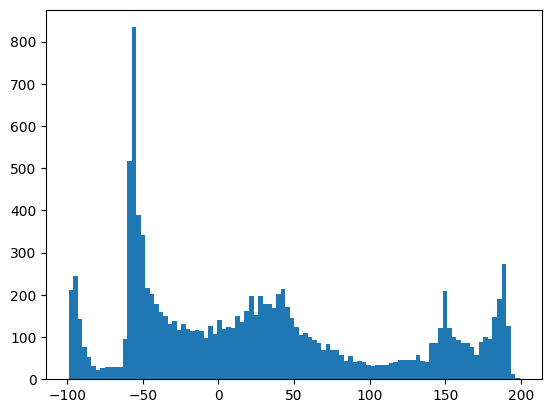

In [ ]:
points = np.loadtxt('my_E_list.txt')
plt.hist(points, bins=100)
plt.show()

zijun

In [ ]:
total_LJ_list=[]
total_q_list=[]
total_E_list=[]
all_list=[]
for p in range(len(surface_positions)): #fix this

      #print(surface_list to know if it is scaled or not)

      translated_o1 = (surface_positions[p] + O1_rotations) #neighbor_positions_opt=np.dot(neighbor_scaled_positions_opt,unitcell)
      translated_o2 = (surface_positions[p] - O1_rotations)

      #scale the positions to unit cell and if not
      scaled_o1=np.dot(translated_o1,inv_unitcell)
      scaled_o2=np.dot(translated_o2,inv_unitcell)

      LJ_co2=[]
      q_co2=[]
      E_co2=[]
      for k in range(len(scaled_o1)):
          surface_O1 = translated_o1[k]
          surface_O2 = translated_o2[k]

          surface_scaled_O1= scaled_o1[k]
          surface_scaled_O2= scaled_o2[k]

          # Interpolate energies for translated points
          energies_o1 = calculate_energy(surface_O1, surface_scaled_O1, scaled_positions, unitcell, epsilon_arr, sigma_arr, charges, epsilon_gas=epsilon_gas_O, sigma_gas=sigma_gas_O, q_gas=q_gas_O)
          energies_o2 = calculate_energy(surface_O2, surface_scaled_O2, scaled_positions, unitcell, epsilon_arr, sigma_arr, charges, epsilon_gas=epsilon_gas_O, sigma_gas=sigma_gas_O, q_gas=q_gas_O)

          total_LJ = energies_o1[0] + energies_o2[0] + Ulj_list[p]
          #print(total_LJ)

          total_q = energies_o1[1] + energies_o2[1] + Uq_list[p]

          total_E = total_LJ + total_q
          LJ_co2.append(total_LJ)

          q_co2.append(total_q)
          E_co2.append(total_E)
      #print(len(LJ_co2))

      min_LJ = np.min(LJ_co2)
      min_q = np.min(q_co2)
      min_E = np.min(E_co2)

      total_LJ_list.append(min_LJ)
      total_q_list.append(min_q)
      total_E_list.append(min_E)




In [ ]:
np.savetxt('surface_features_500probe', total_E_list)

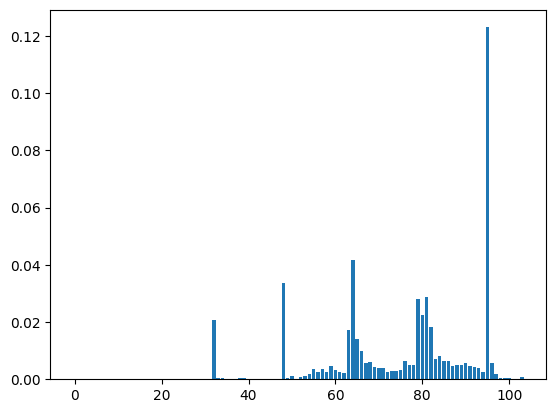

In [ ]:
points = np.loadtxt('/content/surface_features_100probe.txt')
plt.bar(range(len(points[1:105])), points[1:105])
plt.show()

In [ ]:
final_arr=np.vstack((surface_arr.T, total_LJ_list))
final_arr=np.vstack((final_arr, total_q_list)).T
print(final_arr)
output_addr = "/content/output.txt"
#final output [x,y,z,area_density/Angstrom^2, LJ potential/Kelvin, coulumbic]
#np.savetxt(output_addr,final_arr,delimiter=",")

[[  5.0596069   14.36358628  10.0086188    1.25578921 -23.46875058
  -48.13982755]
 [ 10.58872317   6.32266101   0.26000209   1.25578921 -22.49859402
  -48.23483624]
 [ 10.80777472   7.43423121   1.71239823   1.25578921 -22.1331186
  -47.96601662]
 ...
 [ 24.87420015  20.63964267  26.92128715   1.25713728 -21.19934615
  -18.58384143]
 [ 25.14882584  20.83522074  25.93340277   1.25713728 -23.29965408
  -11.45194192]
 [ 22.79175939  21.78549287  25.68607457   1.25713728 -24.26960458
  -11.3693196 ]]


In [ ]:
#total surface area
accessible_surface_area=sum(np.array(surface_list)[:,3])
print(accessible_surface_area)

5679.007458709844


##Construct Histogram

In [ ]:
#histogram construction
Ulj_arr=np.array(total_LJ_list)
Ulj_arr = np.where(Ulj_arr > 0, 0.0, Ulj_arr)
Ulj_arr = np.where(Ulj_arr <= -40, -39.9, Ulj_arr)
Uq_arr=np.array(total_q_list)
Uq_arr = np.where(Uq_arr > 40, 39.9, Uq_arr)
Uq_arr = np.where(Uq_arr <= -40, -39.9, Uq_arr)
Uljq_arr=np.vstack((Ulj_arr,Uq_arr))
Uanddensity_arr=np.vstack((Uljq_arr,surface_arr[:,3])).T


bin_list=[]
for m in np.linspace(-35, 0, num=8):
    for q in np.linspace(-35, 40, num=16): #to determine
        bin_Uanddensity=Uanddensity_arr[np.logical_and(Uanddensity_arr[:,0]>(m-5.0),Uanddensity_arr[:,0]<=m)]
        bin_Uanddensity=bin_Uanddensity[np.logical_and(bin_Uanddensity[:,1]>(q-5.0),bin_Uanddensity[:,1]<=q)]
        bin_U=np.sum(bin_Uanddensity[:,2]) #sum area of points within a spcific energy level
        bin_list.append(bin_U)
result_hist=[accessible_surface_area/volume/density*10000]+(bin_list/accessible_surface_area).tolist()
#np.savetxt('hist -40.txt', result_hist)

## Radial Distribution Function

#### RDF 1

In [ ]:

Ulj_arr=np.array(total_LJ_list)
Ulj_arr = np.where(Ulj_arr > 0, 0.0, Ulj_arr)
Ulj_arr = np.where(Ulj_arr <= -40, -39.9, Ulj_arr)
Uq_arr=np.array(total_q_list)
Uq_arr = np.where(Uq_arr > 20, 20.0, Uq_arr)
Uq_arr = np.where(Uq_arr <= -40, -39.9, Uq_arr)
Uljq_arr=np.vstack((Ulj_arr,Uq_arr))
Uanddensity_arr=np.vstack((Uljq_arr,surface_arr[:,3])).T

n_bin=12

rdf_list=[]
final_arr_2=np.vstack((surface_arr.T,Ulj_arr))
final_arr_2=np.vstack((final_arr_2,Uq_arr)).T

In [ ]:
#analyze the spatial arrangement of atoms or molecules in a system.
#It describes the probability of finding a particle at a specific distance from a reference particle within a given material.
#we pick the points that have the desired energies and recompute the distnence
for i in list(range(-35,1,5)):
    for j in list(range(-20,21,20)):
        pcl=final_arr_2[final_arr_2[:,4]<i] #select based on ljE less than i
        pcl=pcl[pcl[:,5]<j] #select from filtered based on ljE those with qE less than j
        pcl=pcl[pcl[:,5]>(j-20.0)][:,0:3] #selecting first coordinates where qE greater than condition
        pcl_scaled=np.dot(pcl,inv_unitcell) #scaled filtered coordinates
        bin_arr_final=np.array([0.0]*n_bin) #initialize zeros in number of bins
        num_point=len(pcl_scaled[:,0]) #no of elements in filtered subset
        bin_radius_arr=np.linspace(12.0/n_bin,12.0,num=n_bin) #boundaries for radial bins ????

        for m in range(num_point):
        #calculating neighbours based on coordinates
            pcl_scaled_opt=pcl_scaled+np.round(pcl_scaled[m]-pcl_scaled) #ask ????
            pcl_opt=np.dot(pcl_scaled_opt,unitcell) #scale
            neighbor_distances=np.linalg.norm(pcl[m]-pcl_opt,axis=1) #compute euclidean distance between a filtered points and the rest of the points
            bin_arr=np.array([])
            for b in bin_radius_arr:
               #for distances ???
                bin_arr=np.append(bin_arr,len(neighbor_distances[np.logical_and(neighbor_distances<b,neighbor_distances>=b-12.0/n_bin)]))
            bin_arr_final=bin_arr_final+bin_arr

        #volume
        volume_weight=4/3*np.pi*(np.power(bin_radius_arr,3)-np.power(bin_radius_arr-12.0/n_bin,3))
        rdf=bin_arr_final/volume_weight/num_point
        rdf_list=rdf_list+rdf.tolist()
rdf1_list = np.nan_to_num(rdf_list, nan=0.0)

#### RDF 2

In [ ]:

Ulj_arr=np.array(total_LJ_list)
Ulj_arr = np.where(Ulj_arr > 0, 0.0, Ulj_arr)
Ulj_arr = np.where(Ulj_arr <= -40, -39.9, Ulj_arr)
Uq_arr=np.array(total_q_list)
Uq_arr = np.where(Uq_arr > 40, 39.9, Uq_arr)
Uq_arr = np.where(Uq_arr <= -40, -39.9, Uq_arr)
Uljq_arr=np.vstack((Ulj_arr,Uq_arr))
Uanddensity_arr=np.vstack((Uljq_arr,surface_arr[:,3])).T

n_bin=6

rdf_list=[]
final_arr_2=np.vstack((surface_arr.T,Ulj_arr))
final_arr_2=np.vstack((final_arr_2,Uq_arr)).T


for i in list(range(-30,1,10)):
#for i in list(range(-0,1,10)):
    for j in list(range(1,5)):
        #print(i,j)
        pcl0=final_arr_2[final_arr_2[:,4]<i]
        pcl=pcl0[pcl0[:,5]<-40.0+10*j][:,0:3]
        pcl_scaled=np.dot(pcl,inv_unitcell)
        pcl2=pcl0[pcl0[:,5]>40.0-10*j][:,0:3]
        pcl2_scaled=np.dot(pcl2,inv_unitcell)
        bin_arr_final=np.array([0.0]*n_bin)
        num_point=len(pcl_scaled[:,0])
        bin_radius_arr=np.linspace(6.0/n_bin,6.0,num=n_bin)
        for m in range(num_point):
        #m=0
            pcl_scaled_opt=pcl2_scaled+np.round(pcl_scaled[m]-pcl2_scaled)
            pcl_opt=np.dot(pcl_scaled_opt,unitcell)
            neighbor_distances=np.linalg.norm(pcl[m]-pcl_opt,axis=1)
            bin_arr=np.array([])
            for b in bin_radius_arr:
                bin_arr=np.append(bin_arr,len(neighbor_distances[np.logical_and(neighbor_distances<b,neighbor_distances>=b-6.0/n_bin)]))
            bin_arr_final=bin_arr_final+bin_arr
        #bin_arr_final
        volume_weight=4/3*np.pi*(np.power(bin_radius_arr,3)-np.power(bin_radius_arr-6.0/n_bin,3))
        rdf=bin_arr_final/volume_weight/num_point
        rdf_list=rdf_list+rdf.tolist()
    #rdf
rdf2_list = np.nan_to_num(rdf_list, nan=0.0)

#### RDF 3

In [ ]:
Ulj_arr=np.array(total_LJ_list)
Ulj_arr = np.where(Ulj_arr > 0, 0.0, Ulj_arr)
Ulj_arr = np.where(Ulj_arr <= -40, -39.9, Ulj_arr)
Uq_arr=np.array(total_q_list)
Uq_arr = np.where(Uq_arr > 40, 39.9, Uq_arr)
Uq_arr = np.where(Uq_arr <= -20, -19.9, Uq_arr)
Uljq_arr=np.vstack((Ulj_arr,Uq_arr))
Uanddensity_arr=np.vstack((Uljq_arr,surface_arr[:,3])).T
n_bin=12
rdf_list=[]
final_arr_2=np.vstack((surface_arr.T,Ulj_arr))
final_arr_2=np.vstack((final_arr_2,Uq_arr)).T


for i in list(range(-35,1,5)):
    for j in list(range(0,41,20)):
        pcl=final_arr_2[final_arr_2[:,4]<i]
        pcl=pcl[pcl[:,5]<j]
        pcl=pcl[pcl[:,5]>(j-20.0)][:,0:3]
        pcl_scaled=np.dot(pcl,inv_unitcell)
        bin_arr_final=np.array([0.0]*n_bin)
        num_point=len(pcl_scaled[:,0])
        bin_radius_arr=np.linspace(12.0/n_bin,12.0,num=n_bin)
        for m in range(num_point):
        #m=0
            pcl_scaled_opt=pcl_scaled+np.round(pcl_scaled[m]-pcl_scaled)
            pcl_opt=np.dot(pcl_scaled_opt,unitcell)
            neighbor_distances=np.linalg.norm(pcl[m]-pcl_opt,axis=1)
            bin_arr=np.array([])
            for b in bin_radius_arr:
                bin_arr=np.append(bin_arr,len(neighbor_distances[np.logical_and(neighbor_distances<b,neighbor_distances>=b-12.0/n_bin)]))
            bin_arr_final=bin_arr_final+bin_arr
        #bin_arr_final
        volume_weight=4/3*np.pi*(np.power(bin_radius_arr,3)-np.power(bin_radius_arr-12.0/n_bin,3))
        rdf=bin_arr_final/volume_weight/num_point
        rdf_list=rdf_list+rdf.tolist()
rdf3_list = np.nan_to_num(rdf_list, nan=0.0)

In [ ]:
np.savetxt('co2_features_hist.txt', result_hist)

np.savetxt('co2_features_hist+rdf.txt', result_hist+rdf1_list.tolist()+rdf2_list.tolist()+rdf3_list.tolist())

### Total

In [ ]:
final_arr=np.vstack((surface_arr.T,total_E_list)).T
#np.savetxt(output_addr,final_arr,delimiter=",")

accessible_surface_area=sum(np.array(surface_list)[:,3])

U_arr=np.array(total_E_list)
U_arr = np.where(U_arr > 0, 0.0, U_arr)
U_arr = np.where(U_arr <= -40, -39.9, U_arr)
Uanddensity_arr=np.vstack((U_arr,surface_arr[:,3].T)).T

bin_list=[]
for m in np.linspace(-35, 0, num=8):
    bin_Uanddensity=Uanddensity_arr[np.logical_and(Uanddensity_arr[:,0]>(m-5.0),Uanddensity_arr[:,0]<=m)]
    bin_U=np.sum(bin_Uanddensity[:,1])
    bin_list.append(bin_U)
result_hist_c=[accessible_surface_area/volume/density*10000]+(bin_list/accessible_surface_area).tolist()

In [ ]:
U_arr=np.array(total_E_list)
U_arr = np.where(U_arr > 0, 0.0, U_arr)
U_arr = np.where(U_arr <= -40, -39.9, U_arr)

Uanddensity_arr=np.vstack((U_arr,surface_arr[:,3].T)).T
n_bin=12
rdf_list=[]
final_arr_2=np.vstack((surface_arr.T,U_arr)).T

for i in list(range(-35,1,5)):
    pcl=final_arr_2[final_arr_2[:,4]<i][:,0:3]
    pcl_scaled=np.dot(pcl,inv_unitcell)
    bin_arr_final=np.array([0.0]*n_bin)
    num_point=len(pcl_scaled[:,0])
    bin_radius_arr=np.linspace(12.0/n_bin,12.0,num=n_bin)
    for m in range(num_point):
        pcl_scaled_opt=pcl_scaled+np.round(pcl_scaled[m]-pcl_scaled)
        pcl_opt=np.dot(pcl_scaled_opt,unitcell)
        neighbor_distances=np.linalg.norm(pcl[m]-pcl_opt,axis=1)
        bin_arr=np.array([])
        for b in bin_radius_arr:
            bin_arr=np.append(bin_arr,len(neighbor_distances[np.logical_and(neighbor_distances<b,neighbor_distances>=b-12.0/n_bin)]))
        bin_arr_final=bin_arr_final+bin_arr
    #bin_arr_final
    volume_weight=4/3*np.pi*(np.power(bin_radius_arr,3)-np.power(bin_radius_arr-12.0/n_bin,3))
    rdf=bin_arr_final/volume_weight/num_point
    rdf_list=rdf_list+rdf.tolist()
rdf1_list = np.nan_to_num(rdf_list, nan=0.0)




np.savetxt('co2_features_100.txt', result_hist_c+rdf1_list.tolist())

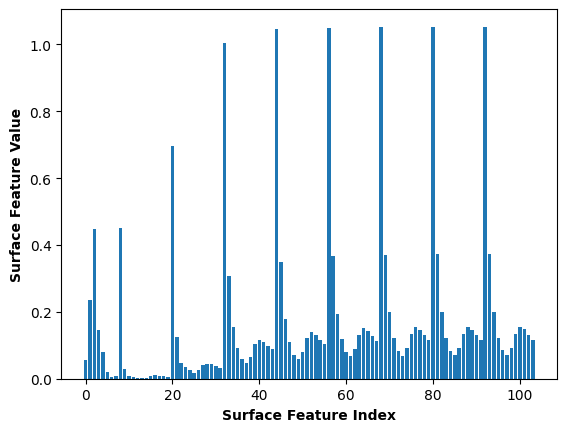

In [ ]:
points = np.loadtxt('/content/co2_features_100.txt')
plt.bar(range(len(points[1:])), points[1:])
plt.xlabel('Surface Feature Index', fontsize=10, fontweight='bold')
plt.ylabel('Surface Feature Value', fontsize=10, fontweight='bold')
plt.show()

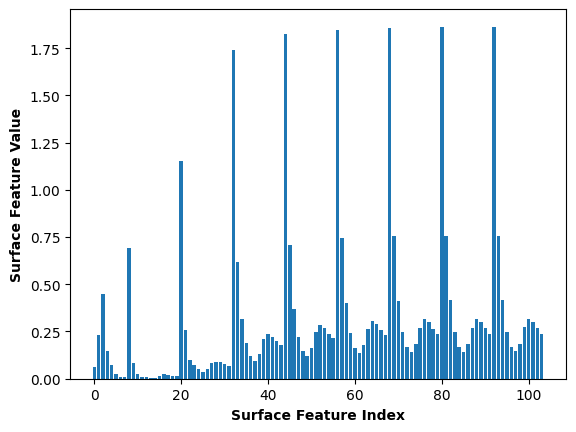

In [ ]:
points = np.loadtxt('/content/co2_features_200.txt')
plt.bar(range(len(points[1:])), points[1:])
plt.xlabel('Surface Feature Index', fontsize=10, fontweight='bold')
plt.ylabel('Surface Feature Value', fontsize=10, fontweight='bold')
plt.show()

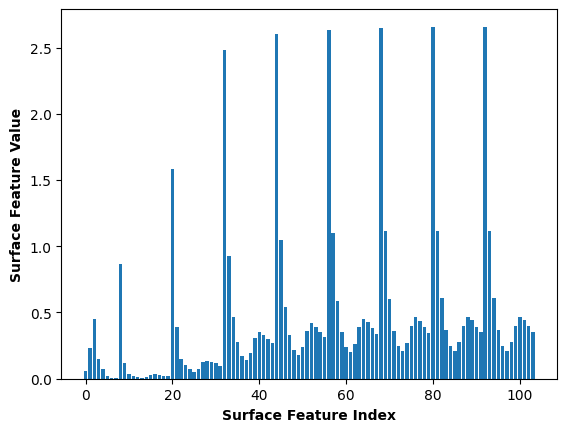

In [ ]:
points = np.loadtxt('/content/co2_features_300.txt')
plt.bar(range(len(points[1:])), points[1:])
plt.xlabel('Surface Feature Index', fontsize=10, fontweight='bold')
plt.ylabel('Surface Feature Value', fontsize=10, fontweight='bold')
plt.show()

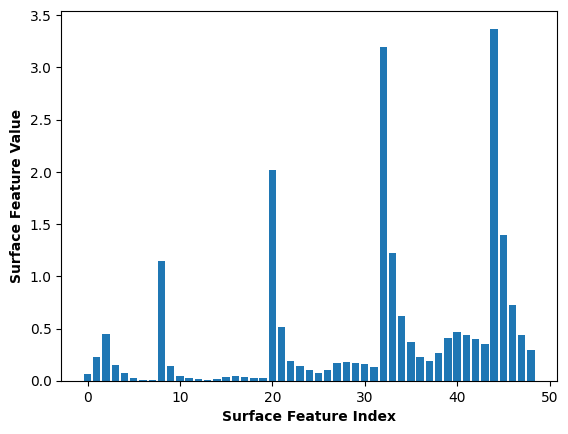

In [ ]:
points = np.loadtxt('/content/co2_features_400.txt')
plt.bar(range(len(points[1:50])), points[1:50])
plt.xlabel('Surface Feature Index', fontsize=10, fontweight='bold')
plt.ylabel('Surface Feature Value', fontsize=10, fontweight='bold')
plt.show()

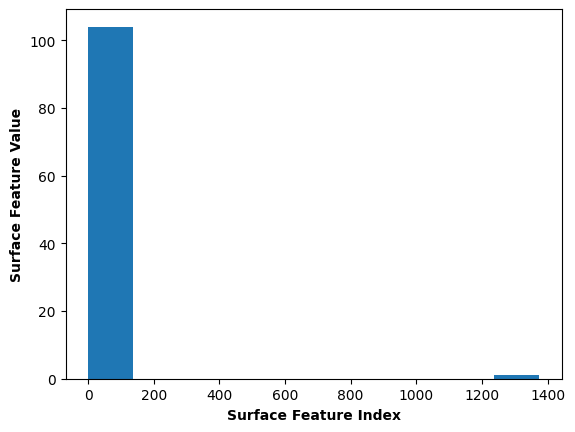

In [ ]:
points = np.loadtxt('/content/co2_features_500.txt')
#plt.bar(range(len(points[1:])), points[1:])
plt.xlabel('Surface Feature Index', fontsize=10, fontweight='bold')
plt.ylabel('Surface Feature Value', fontsize=10, fontweight='bold')
plt.show()

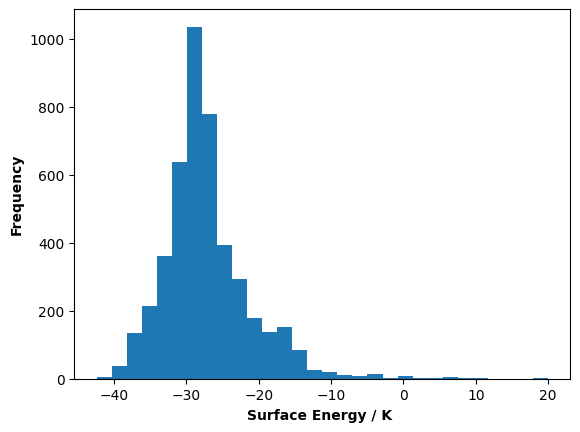

In [ ]:
# Load the points from the file
points = np.loadtxt('/content/surface_features_100probe')

# Plot the histogram
plt.hist(points[0:5000], bins=30)  # You can adjust the number of bins if necessary

# Set labels
plt.xlabel('Surface Energy / K ', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

# Show the plot
plt.show()

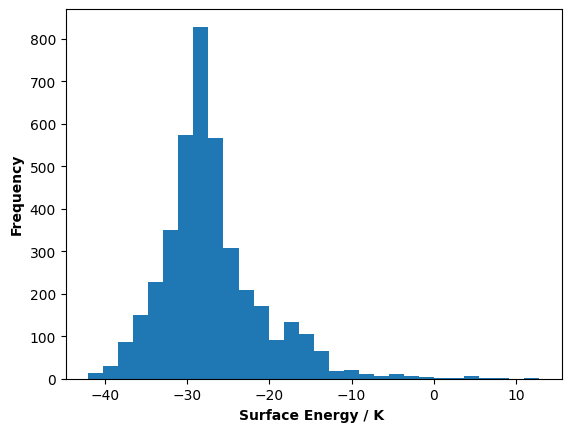

In [ ]:
# Load the points from the file
points = np.loadtxt('/content/surface_features_200probe')

# Plot the histogram
plt.hist(points[0:4000], bins=30)  # You can adjust the number of bins if necessary

# Set labels
plt.xlabel('Surface Energy / K ', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

# Show the plot
plt.show()

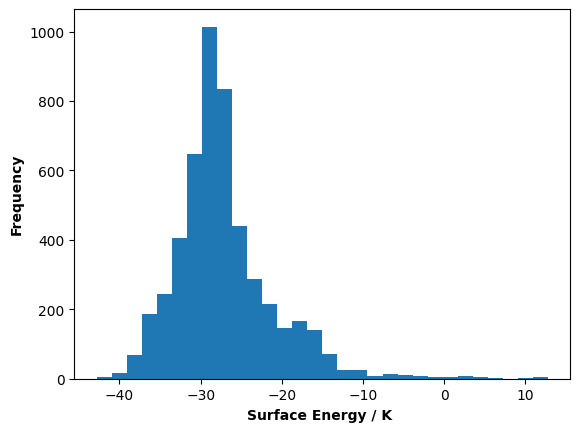

In [ ]:
# Load the points from the file
points = np.loadtxt('/content/surface_features_300probe')

# Plot the histogram
plt.hist(points[0:5000], bins=30)  # You can adjust the number of bins if necessary

# Set labels
plt.xlabel('Surface Energy / K ', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

# Show the plot
plt.show()

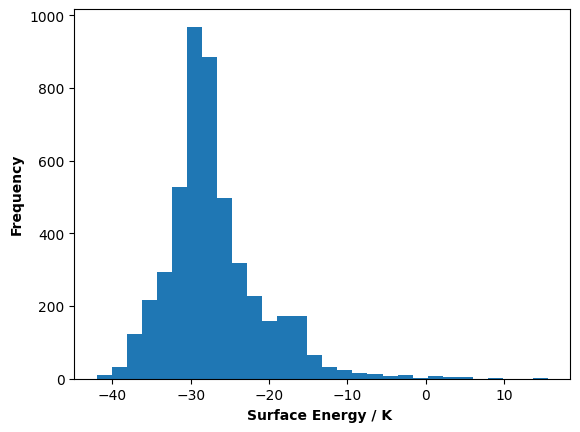

In [ ]:
# Load the points from the file
points = np.loadtxt('/content/surface_features_400probe')

# Plot the histogram
plt.hist(points[0:5000], bins=30)  # You can adjust the number of bins if necessary

# Set labels
plt.xlabel('Surface Energy / K ', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

# Show the plot
plt.show()

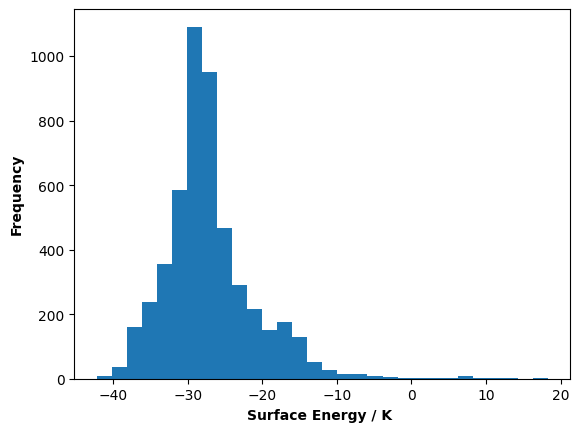

In [ ]:
# Load the points from the file
points = np.loadtxt('/content/surface_features_500probe')

# Plot the histogram
plt.hist(points[0:5000], bins=30)  # You can adjust the number of bins if necessary

# Set labels
plt.xlabel('Surface Energy / K ', fontsize=10, fontweight='bold')
plt.ylabel('Frequency', fontsize=10, fontweight='bold')

# Show the plot
plt.show()